#**UTS soal 2**
#**Analisa Clutering**

**Import Library**

In [1]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
pip install sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.0 MB/s eta 0:00:00


**Input Data**

In [3]:
#Menampilkan Data
import pandas as pd

# Baca file yang sudah diunggah
df = pd.read_csv("spam.csv", encoding='latin-1')


# Lihat nama-nama kolom dan contoh data
print("Nama-nama kolom:")
print(df.columns)

print("\nContoh 100 baris pertama:")
print(df.head())

Nama-nama kolom:
Index(['id', 'Text', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

Contoh 100 baris pertama:
   id                                               Text Unnamed: 2  \
0   1  Go until jurong point, crazy.. Available only ...        NaN   
1   2                      Ok lar... Joking wif u oni...        NaN   
2   3  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   4  U dun say so early hor... U c already then say...        NaN   
4   5  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [4]:
print(df.columns)


Index(['id', 'Text', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [5]:
kolom_teks = 'Text'
df = df[[kolom_teks]].dropna()


**Prepocessing**

In [6]:
# Stopword lokal
stopword_indonesia = set([
    "yang", "dan", "di", "ke", "dari", "ini", "itu", "untuk", "dengan", "karena",
    "ada", "saya", "kami", "kita", "mereka", "pada", "adalah", "juga", "tidak",
    "ya", "kok", "loh", "banget", "sih", "jadi", "udah", "lagi", "aja", "dong", "nih"
])

# Normalisasi kata
normalisasi_kata = {
    "bangeettt": "banget", "bgt": "banget", "bgtt": "banget",
    "gk": "tidak", "ga": "tidak", "nggak": "tidak",
    "dr": "dari", "tp": "tapi", "tdk": "tidak",
    "sy": "saya", "lg": "lagi"
}

def normalize_kata(tokens):
    return [normalisasi_kata.get(word, word) for word in tokens]

def simple_tokenize(text):
    return text.split()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = simple_tokenize(text)
    tokens = normalize_kata(tokens)
    tokens = [word for word in tokens if word not in stopword_indonesia and len(word) > 2]
    return " ".join(tokens)

# Terapkan preprocessing
df['preprocessed'] = df['Text'].astype(str).apply(preprocess)

In [7]:
import re
import pandas as pd
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Buat stemmer Sastrawi
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Ambil 5 data awal
sample_data = df['Text'].astype(str).head(5)

# List untuk simpan hasil
stopwords_removed = []
cleaning = []
normalized = []
stemming = []
tokenizing = []

for text in sample_data:
    # Tokenisasi awal (pisah kata)
    tokens = text.split()

    # Stopword removal
    tokens_sw = [word for word in tokens if word not in stopword_indonesia and len(word) > 2]
    stopwords_removed.append(tokens_sw)

    # Cleaning (hapus karakter non-huruf)
    tokens_clean = [re.sub(r'[^a-zA-Z]', '', word) for word in tokens_sw if re.sub(r'[^a-zA-Z]', '', word) != ""]
    cleaning.append(tokens_clean)

    # Normalisasi (pembakuan kata)
    tokens_norm = [normalisasi_kata.get(word.lower(), word.lower()) for word in tokens_clean]
    normalized.append(tokens_norm)

    # Stemming
    tokens_stem = [stemmer.stem(word) for word in tokens_norm]
    stemming.append(tokens_stem)

    # Tokenisasi akhir
    tokenizing.append(tokens_stem)

# Simpan hasil ke DataFrame
tahapan_df = pd.DataFrame({
    'Asli': sample_data,
    'Stopword Removal': stopwords_removed,
    'Cleaning': cleaning,
    'Normalisasi (Ejaan Baku)': normalized,
    'Stemming': stemming,
    'Tokenisasi Akhir': tokenizing
})

# Tampilkan hasil
from IPython.display import display
display(tahapan_df)


,Asli,Stopword Removal,Cleaning,Normalisasi (Ejaan Baku),Stemming,Tokenisasi Akhir
0,"Go until jurong point, crazy.. Available only ...","[until, jurong, point,, crazy.., Available, on...","[until, jurong, point, crazy, Available, only,...","[until, jurong, point, crazy, available, only,...","[until, jurong, point, crazy, available, only,...","[until, jurong, point, crazy, available, only,..."
1,Ok lar... Joking wif u oni...,"[lar..., Joking, wif, oni...]","[lar, Joking, wif, oni]","[lar, joking, wif, oni]","[lar, joking, wif, oni]","[lar, joking, wif, oni]"
2,Free entry in 2 a wkly comp to win FA Cup fina...,"[Free, entry, wkly, comp, win, Cup, final, tkt...","[Free, entry, wkly, comp, win, Cup, final, tkt...","[free, entry, wkly, comp, win, cup, final, tkt...","[free, entry, wkly, comp, win, cup, final, tkt...","[free, entry, wkly, comp, win, cup, final, tkt..."
3,U dun say so early hor... U c already then say...,"[dun, say, early, hor..., already, then, say...]","[dun, say, early, hor, already, then, say]","[dun, say, early, hor, already, then, say]","[dun, say, early, hor, already, then, say]","[dun, say, early, hor, already, then, say]"
4,"Nah I don't think he goes to usf, he lives aro...","[Nah, don't, think, goes, usf,, lives, around,...","[Nah, dont, think, goes, usf, lives, around, h...","[nah, dont, think, goes, usf, lives, around, h...","[nah, dont, think, goes, usf, lives, around, h...","[nah, dont, think, goes, usf, lives, around, h..."


In [8]:
text_col = 'v2' if 'v2' in df.columns else df.columns[-1]
sample_data = df[text_col].astype(str)


In [19]:
import re
import pandas as pd
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# --- 1️⃣ Baca file CSV dengan encoding aman ---
# 'latin-1' mencegah UnicodeDecodeError
df = pd.read_csv('spam.csv', encoding='latin-1')

# Cek nama kolom
print("Kolom dalam dataset:", df.columns)

# --- 2️⃣ Tentukan kolom teks ---
# Ganti 'v2' jika nama kolom teks berbeda
sample_data = df['Text'].astype(str)

# --- 3️⃣ Buat stemmer & stopword list dari Sastrawi ---
factory = StemmerFactory()
stemmer = factory.create_stemmer()

stopword_factory = StopWordRemoverFactory()
stopword_indonesia = set(stopword_factory.get_stop_words())

# --- 4️⃣ Kamus normalisasi sederhana ---
normalisasi_kata = {
    'gk': 'tidak', 'nggak': 'tidak', 'ga': 'tidak',
    'yg': 'yang', 'dlm': 'dalam', 'tp': 'tapi',
    'kalo': 'kalau', 'aja': 'saja', 'makasih': 'terima kasih'
}

# --- 5️⃣ List untuk menyimpan hasil preprocessing ---
stopwords_removed = []
cleaning = []
normalized = []
stemming = []
tokenizing = []

for text in sample_data:
    # Case folding (ubah ke huruf kecil)
    text = text.lower()

    # Tokenisasi awal (pisahkan kata dengan regular expression)
    tokens = re.findall(r'\b\w+\b', text)

    # Stopword removal
    tokens_sw = [word for word in tokens if word not in stopword_indonesia and len(word) > 2]
    stopwords_removed.append(tokens_sw)

    # Cleaning (hapus karakter non-huruf, jaga hasil tidak kosong)
    tokens_clean = [re.sub(r'[^a-zA-Z]', '', word) for word in tokens_sw if re.sub(r'[^a-zA-Z]', '', word) != ""]
    cleaning.append(tokens_clean)

    # Normalisasi
    tokens_norm = [normalisasi_kata.get(word, word) for word in tokens_clean]
    normalized.append(tokens_norm)

    # Stemming
    tokens_stem = [stemmer.stem(word) for word in tokens_norm]
    stemming.append(tokens_stem)

    # Tokenisasi akhir
    tokenizing.append(tokens_stem)

# --- 6️⃣ Gabungkan ke DataFrame ---
tahapan_df = pd.DataFrame({
    'Teks Asli': sample_data,
    'Setelah Stopword Removal': stopwords_removed,
    'Setelah Cleaning': cleaning,
    'Setelah Normalisasi': normalized,
    'Setelah Stemming': stemming,
    'Tokenisasi Akhir': tokenizing
})

# --- 7️⃣ Simpan hasil ke file lokal ---
output_path = "hasil_preprocessing_spam.csv"
tahapan_df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"✅ File hasil preprocessing disimpan di: {output_path}")


Kolom dalam dataset: Index(['id', 'Text', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')
✅ File hasil preprocessing disimpan di: hasil_preprocessing_Berita.csv


**TF-IDF**

In [20]:
!pip install scikit-learn

In [21]:
import pandas as pd
import ast
from sklearn.feature_extraction.text import TfidfVectorizer

In [23]:
# Baca CSV dari path Drive
df = pd.read_csv('hasil_preprocessing_spam.csv')
df.head()

,Teks Asli,Setelah Stopword Removal,Setelah Cleaning,Setelah Normalisasi,Setelah Stemming,Tokenisasi Akhir
0,"Go until jurong point, crazy.. Available only ...","['until', 'jurong', 'point', 'crazy', 'availab...","['until', 'jurong', 'point', 'crazy', 'availab...","['until', 'jurong', 'point', 'crazy', 'availab...","['until', 'jurong', 'point', 'crazy', 'availab...","['until', 'jurong', 'point', 'crazy', 'availab..."
1,Ok lar... Joking wif u oni...,"['lar', 'joking', 'wif', 'oni']","['lar', 'joking', 'wif', 'oni']","['lar', 'joking', 'wif', 'oni']","['lar', 'joking', 'wif', 'oni']","['lar', 'joking', 'wif', 'oni']"
2,Free entry in 2 a wkly comp to win FA Cup fina...,"['free', 'entry', 'wkly', 'comp', 'win', 'cup'...","['free', 'entry', 'wkly', 'comp', 'win', 'cup'...","['free', 'entry', 'wkly', 'comp', 'win', 'cup'...","['free', 'entry', 'wkly', 'comp', 'win', 'cup'...","['free', 'entry', 'wkly', 'comp', 'win', 'cup'..."
3,U dun say so early hor... U c already then say...,"['dun', 'say', 'early', 'hor', 'already', 'the...","['dun', 'say', 'early', 'hor', 'already', 'the...","['dun', 'say', 'early', 'hor', 'already', 'the...","['dun', 'say', 'early', 'hor', 'already', 'the...","['dun', 'say', 'early', 'hor', 'already', 'the..."
4,"Nah I don't think he goes to usf, he lives aro...","['nah', 'don', 'think', 'goes', 'usf', 'lives'...","['nah', 'don', 'think', 'goes', 'usf', 'lives'...","['nah', 'don', 'think', 'goes', 'usf', 'lives'...","['nah', 'don', 'think', 'goes', 'usf', 'lives'...","['nah', 'don', 'think', 'goes', 'usf', 'lives'..."


In [24]:
print(type(df["Tokenisasi Akhir"].iloc[0]))
print(df["Tokenisasi Akhir"].iloc[0])

<class 'str'>
['until', 'jurong', 'point', 'crazy', 'available', 'only', 'bugis', 'great', 'world', 'buffet', 'cine', 'there', 'got', 'amore', 'wat']


In [25]:
df["Tokenisasi Akhir_joined"] = df["Tokenisasi Akhir"].apply(
    lambda x: " ".join(ast.literal_eval(x)) if isinstance(x, str) else ""
)


df[["Tokenisasi Akhir", "Tokenisasi Akhir_joined"]].head()

,Tokenisasi Akhir,Tokenisasi Akhir_joined
0,"['until', 'jurong', 'point', 'crazy', 'availab...",until jurong point crazy available only bugis ...
1,"['lar', 'joking', 'wif', 'oni']",lar joking wif oni
2,"['free', 'entry', 'wkly', 'comp', 'win', 'cup'...",free entry wkly comp win cup final tkts st may...
3,"['dun', 'say', 'early', 'hor', 'already', 'the...",dun say early hor already then say
4,"['nah', 'don', 'think', 'goes', 'usf', 'lives'...",nah don think goes usf lives around here though


In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# --- 1️⃣ TF-IDF Vectorization ---
vectorizer = TfidfVectorizer(max_features=1000)  # ambil 1000 fitur teratas

X_tfidf = vectorizer.fit_transform(df["Tokenisasi Akhir_joined"])

tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=vectorizer.get_feature_names_out()
)

# --- 2️⃣ Lihat sebagian hasil TF-IDF ---
print("🔹 DataFrame TF-IDF:")
display(tfidf_df.head())

# --- 3️⃣ Tampilkan 10 kata dengan rata-rata TF-IDF tertinggi di seluruh dokumen ---
mean_tfidf = tfidf_df.mean().sort_values(ascending=False)
print("\n🔹 10 Kata dengan rata-rata TF-IDF tertinggi:")
print(mean_tfidf.head(10))

# --- 4️⃣ Tampilkan kata dengan TF-IDF tertinggi per dokumen ---
top_terms_per_doc = tfidf_df.apply(lambda row: row.idxmax(), axis=1)

df_top_terms = pd.concat([df["Tokenisasi Akhir_joined"], top_terms_per_doc], axis=1)
df_top_terms.columns = ["Dokumen", "Kata_TFIDF_Tertinggi"]

print("\n🔹 Kata TF-IDF tertinggi per dokumen:")
display(df_top_terms.head())


🔹 DataFrame TF-IDF:


,abiola,able,about,abt,accept,access,account,across,actually,address,...,yep,yes,yesterday,yet,you,your,yours,yourself,yrs,yup
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



🔹 10 Kata dengan rata-rata TF-IDF tertinggi:
you     0.058917
the     0.038309
and     0.028837
your    0.023802
for     0.023720
call    0.023027
that    0.022581
have    0.021995
are     0.021031
now     0.020337
dtype: float64

🔹 Kata TF-IDF tertinggi per dokumen:


,Dokumen,Kata_TFIDF_Tertinggi
0,until jurong point crazy available only bugis ...,point
1,lar joking wif oni,wif
2,free entry wkly comp win cup final tkts st may...,entry
3,dun say early hor already then say,say
4,nah don think goes usf lives around here though,nah


**Analisis Clustering**

In [33]:
from sklearn.cluster import KMeans


In [34]:
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(tfidf_df)

# Simpan hasil cluster ke DataFrame asli
df['Cluster'] = kmeans.labels_


In [35]:
print("Jumlah dokumen per cluster:")
print(df['Cluster'].value_counts())

# Contoh dokumen per cluster
for i in range(num_clusters):
    print(f"\nCluster {i}:")
    display(df[df['Cluster'] == i][['Tokenisasi Akhir_joined']].head(3))


Jumlah dokumen per cluster:
Cluster
2    3100
4     956
0     733
1     396
3     387
Name: count, dtype: int64

Cluster 0:


,Tokenisasi Akhir_joined
15,xxxmobilemovieclub use your credit click the w...
18,fine thats the way feel thats the way its gota
28,back amp packing the car now let you know ther...



Cluster 1:


,Tokenisasi Akhir_joined
8,winner valued network customer you have been s...
12,urgent you have won week free membership our p...
13,been searching for the right words thank you f...



Cluster 2:


,Tokenisasi Akhir_joined
0,until jurong point crazy available only bugis ...
1,lar joking wif oni
2,free entry wkly comp win cup final tkts st may...



Cluster 3:


,Tokenisasi Akhir_joined
9,had your mobile months more entitled update th...
42,rodger burns msg tried call you your reply our...
56,congrats year special cema pass for yours call...



Cluster 4:


,Tokenisasi Akhir_joined
20,that seriously how you spell his name
24,ffffffffff alright way can meet with you sooner
27,did you catch the bus are you frying egg did y...


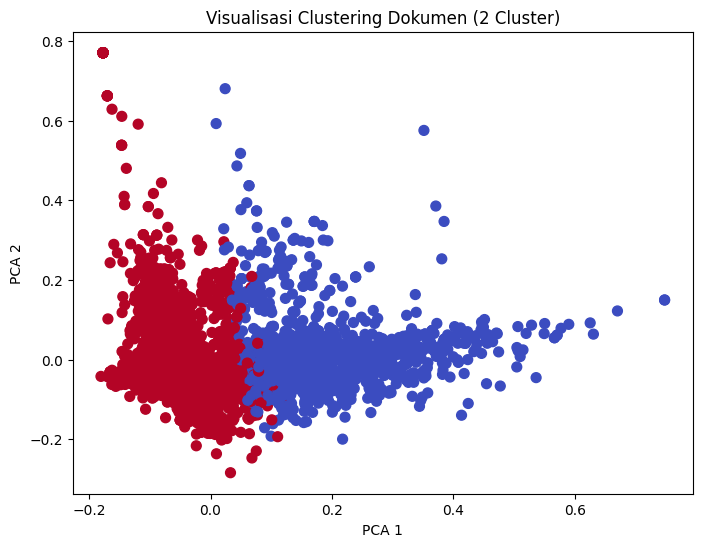

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# --- 1️⃣ TF-IDF ---
vectorizer = TfidfVectorizer(max_features=1000)
X_tfidf = vectorizer.fit_transform(df["Tokenisasi Akhir_joined"])
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=vectorizer.get_feature_names_out())

# --- 2️⃣ Clustering dengan 2 cluster ---
num_clusters = 2
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(tfidf_df)
df["Cluster"] = kmeans.labels_

# --- 3️⃣ Visualisasi dengan PCA (2 warna) ---
pca = PCA(n_components=2, random_state=42)
reduced_features = pca.fit_transform(tfidf_df)

plt.figure(figsize=(8,6))
plt.scatter(reduced_features[:, 0], reduced_features[:, 1],
            c=df["Cluster"], cmap="coolwarm", s=50)
plt.title("Visualisasi Clustering Dokumen (2 Cluster)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


In [42]:
cluster_centers = kmeans.cluster_centers_
terms = vectorizer.get_feature_names_out()

for i in range(num_clusters):
    print(f"\n🧩 Cluster {i} Top Terms:")
    sorted_indices = cluster_centers[i].argsort()[::-1][:10]
    top_terms = [terms[ind] for ind in sorted_indices]
    print(", ".join(top_terms))



🧩 Cluster 0 Top Terms:
you, are, the, and, have, that, how, your, when, can

🧩 Cluster 1 Top Terms:
the, and, for, now, call, your, not, that, but, have
